**WEEK 2 ASSIGNMENT 1**



> MEGHA, CSE-AI 2, 11001172024









In [2]:
#Upload the Dataset
from google.colab import files
uploaded = files.upload()

Saving Dataset 2 (1).csv to Dataset 2 (1).csv


In [3]:
import pandas as pd
df = pd.read_csv("Dataset 2 (1).csv")
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [4]:
print(df.shape)

print(df.columns)

(750, 10)
Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [8]:
print(df.dtypes)

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)



UserID                  int64
Age                     int64
Gender                 object
SubscriptionType       object
WatchHoursPerWeek       int64
DevicesUsed             int64
FavoriteGenre          object
AdClicks                int64
MonthlySpend            int64
SubscriptionRenewed    object
dtype: object
Numerical Features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')

Categorical Features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


In [9]:
#
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [11]:
average_age = df['Age'].mean()
average_WatchHoursPerWeek = df['WatchHoursPerWeek'].mean()
average_MonthlySpend = df['MonthlySpend'].mean()
print("Average Age:", average_age)
print("Average Watch Hours Per Week:", average_WatchHoursPerWeek)
print("Average Monthly Spend:", average_MonthlySpend)

Average Age: 41.824
Average Watch Hours Per Week: 14.236
Average Monthly Spend: 689.9053333333334


In [12]:
renewed_percentage = (df['SubscriptionRenewed'] == 'Yes').mean() * 100

print("Percentage of Users Who Renewed:", round(renewed_percentage, 2), "%")

Percentage of Users Who Renewed: 46.27 %


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())

   UserID  Age  Gender  SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   22       0                 0                 23            5   
1    1002   55       1                 0                  9            4   
2    1003   49       1                 0                  8            3   
3    1004   39       0                 1                 19            5   
4    1005   38       0                 1                 23            5   

   FavoriteGenre  AdClicks  MonthlySpend  SubscriptionRenewed  
0              1        13           353                    0  
1              2        14           317                    1  
2              1        16           309                    0  
3              2        45           833                    1  
4              5        24           804                    1  


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
le = LabelEncoder()

categorical_cols = ['Gender', 'SubscriptionType',
                    'FavoriteGenre', 'SubscriptionRenewed']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('SubscriptionRenewed', axis=1)
y = df['SubscriptionRenewed']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (600, 9)
X_test : (150, 9)
y_train: (600,)
y_test : (150,)


Accuracy: 56.67 %

Confusion Matrix:
[[50 32]
 [33 35]]


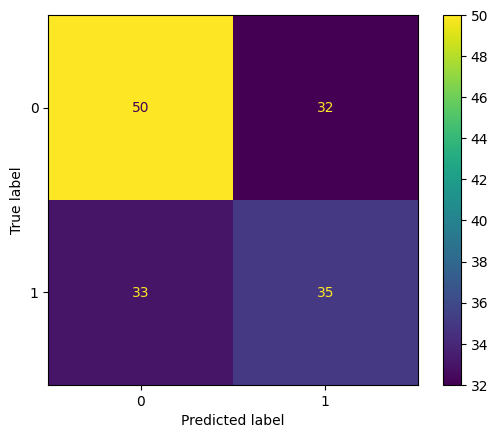

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model with K = 5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [18]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 60.0 %


In [19]:
print("Decision Tree Accuracy:", round(accuracy * 100, 2), "%")
print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")
if knn_accuracy > accuracy:
    print("KNN performs better than Decision Tree.")
elif knn_accuracy < accuracy:
    print("Decision Tree performs better than KNN.")
else:
    print("Both models have the same accuracy.")

Decision Tree Accuracy: 56.67 %
KNN Accuracy: 60.0 %
KNN performs better than Decision Tree.


In [20]:
X = df.drop('MonthlySpend', axis=1)
y = df['MonthlySpend']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 56.85521204825779
MSE: 4918.660344811596
R² Score: 0.9660274555245927
